# Tutorial 01 — Gasificador 0D: Pirólisis en reactor cerrado (Batch)

**Equipo:** Gasificador de lecho fijo · **Modo:** 0D (N=1) · Batch (sin flujo de gas externo)  
**Fenómeno:** Pirólisis y secado de biomasa con calefacción externa  
**Nivel:** Introductorio — punto de partida para comprender el gasificador

## Introducción

Este tutorial cubre el caso más simple del gasificador: un **reactor concentrado (0D)** con biomasa
y sin flujo de gas externo.

### ¿Qué es el modo 0D?

Cuando el número de celdas es **N = 1**, el modelo se interpreta como **0D** (cero dimensional):
el reactor se representa como un único volumen perfectamente mezclado. No existe una dirección
espacial interna ni caras entre volúmenes de control.

**Consecuencia directa:** en 0D no tiene sentido hablar de velocidades axiales internas.
Las únicas variables de transporte son las condiciones globales de entrada y salida del reactor.

### ¿Qué es el modo Batch?

En modo batch **no se inyecta agente gasificante externo** (`v_gas_in = None`) y **la salida
está sellada** (`v_out = 0.0`). El sistema evoluciona desde sus condiciones iniciales únicamente
por reacciones internas:

1. **Secado**: la humedad libre de la biomasa se evapora (H₂O → gas)
2. **Pirólisis**: la biomasa se descompone en char, gases permanentes (CO, CO₂, H₂, CH₄) y tar
3. **Reacciones de char**: si la temperatura y el entorno lo permiten, el char puede reaccionar

El gas producido **no puede salir** — se acumula en el reactor y la presión sube libremente.
Esto es diferente del modo semibatch (Tutorial 02), donde una válvula de alivio controla la presión.

### Caso físico representado

Una muestra de biomasa (abeto, softwood spruce) cargada en un pequeño tubo reactor que se calienta
externamente desde temperatura ambiente (300 K) hasta 800 °C (1073 K) mantenidos en la pared.

Este es el punto de partida para entender:
- cómo evoluciona la fase sólida (biomasa → char)
- qué gases produce la pirólisis y en qué proporción
- cómo se distribuye la energía entre las fases gas y sólido
- cómo verificar el cierre de los balances de masa y energía

In [85]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ajustar ruta al raíz del proyecto (test/gasifier/ → ../../)
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader import read_fueldb
from src.units.gasifier.config.gas_props    import build_gas_prop_config, GASIFIER_GAS_SPECIES
from src.units.gasifier.config.solid_props  import build_solid_prop_config
from src.units.gasifier.config.transport    import build_transport_config
from src.units.gasifier.config.thermal_bc   import build_thermal_bc_config
from src.units.gasifier.config.boundary_c   import build_bc_config
from src.units.gasifier.config.initial_c    import build_initial_c_config
from src.solvers.runner_gasifier            import run_step
from src.postprocessing.gasifier_balances   import check_balances, display_balances
from src.postprocessing.gasifier_plots      import (
    plot_temperatures, plot_solid_evolution,
    plot_gas_composition, plot_pressure,
)

print(f"ROOT: {ROOT}")

ROOT: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-gasifier


## 1. Bases de datos y propiedades del combustible

In [86]:
# Rutas a bases de datos
FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
GAS_DB    = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
SOLID_DB  = os.path.join(ROOT, "materials", "solids", "soliddb.txt")

# Carga del combustible
fuel_config = read_fueldb(FUEL_PATH)

# Resumen del combustible cargado
rho_p = float(fuel_config["physical"]["rho_particle"])   # [kg/m³]
dp0   = float(fuel_config["physical"]["dp_initial"])     # [m]
print(f"Combustible : {fuel_config['description']}")
print(f"ρ_partícula : {rho_p:.0f} kg/m³")
print(f"dp_inicial  : {dp0*1000:.1f} mm")

Combustible : Softwood (spruce) for fixed-bed updraft gasification
ρ_partícula : 430 kg/m³
dp_inicial  : 10.0 mm


## 2. Geometría y condiciones de operación

Se define un tubo reactor pequeño (≈ 1 L de volumen interno) para tener un caso
numéricamente manejable con significado físico claro.

In [87]:
# ── Geometría ────────────────────────────────────────────────────────────────
N  = 1       # Número de celdas → modelo 0D (volumen perfectamente mezclado)
L  = 0.10    # [m]  longitud del reactor
Di = 0.10    # [m]  diámetro interno
Do = 0.114   # [m]  diámetro externo (e_pared = 7 mm, acero inox 316L)

dz     = L / N                     # [m]   tamaño de celda
Ai     = 0.25 * np.pi * Di**2      # [m²]  sección transversal interna
Pi     = np.pi * Di                # [m]   perímetro interno
Po     = np.pi * Do                # [m]   perímetro externo
e_wall = (Do - Di) / 2             # [m]   espesor de pared

# ── Condiciones de operación ─────────────────────────────────────────────────
epsi_r = 0.60       # [-]   porosidad del lecho (fracción de huecos gas/volumen lecho)
P_out  = 1.01325    # [bar] presión de salida (atmósfera)

# ── Carga inicial de biomasa ─────────────────────────────────────────────────
mc_wb       = 0.15                                          # [-]       contenido de humedad base húmeda
rho_bio_dry = rho_p * (1 - epsi_r)                          # [kg/m³_bed] biomasa seca en lecho
rho_moi_0   = rho_bio_dry * mc_wb / (1 - mc_wb)             # [kg/m³_bed] humedad inicial
rho_bio_0   = rho_bio_dry                                   # [kg/m³_bed] biomasa inicial
rho_char_0  = 1e-6                                          # [kg/m³_bed] traza de char inicial

# Densidad de referencia del char (para modelo de partícula decreciente SCM)
rho_char0 = fuel_config["pyrolysis_yields"]["char"] * rho_p * (1 - epsi_r)

print(f"Geometría:")
print(f"  N = {N} celdas → modelo 0D")
print(f"  V_reactor = {Ai*L*1e6:.1f} cm³  (Di={Di*100:.0f} cm, L={L*100:.0f} cm)")
print(f"\nCarga inicial de sólido:")
print(f"  ρ_biomasa  = {rho_bio_0:.1f} kg/m³_bed")
print(f"  ρ_humedad  = {rho_moi_0:.1f} kg/m³_bed  ({mc_wb*100:.0f} % wb)")
print(f"  ρ_char_ini = {rho_char_0:.1e} kg/m³_bed  (traza)")

Geometría:
  N = 1 celdas → modelo 0D
  V_reactor = 785.4 cm³  (Di=10 cm, L=10 cm)

Carga inicial de sólido:
  ρ_biomasa  = 172.0 kg/m³_bed
  ρ_humedad  = 30.4 kg/m³_bed  (15 % wb)
  ρ_char_ini = 1.0e-06 kg/m³_bed  (traza)


## 3. Condiciones iniciales del gas

El espacio de huecos del lecho está inicialmente lleno de N₂ inerte a temperatura ambiente.
No hay productos de reacción al inicio.

In [88]:
T_init = 300.0    # [K] temperatura inicial de gas y sólido (≈ 27 °C)

species = list(GASIFIER_GAS_SPECIES)   # ['CO','CO2','H2O','H2','O2','CH4','C2H4','tar','N2']
nc      = len(species)                 # 9 especies

y0 = np.zeros(nc)
y0[species.index("N2")] = 1.0    # 100 % N₂ al inicio

print(f"Temperatura inicial: {T_init:.1f} K ({T_init-273.15:.1f} °C)")
print(f"Composición inicial: 100 % N₂")
print(f"Presión inicial: {P_out:.5f} bar")

Temperatura inicial: 300.0 K (26.9 °C)
Composición inicial: 100 % N₂
Presión inicial: 1.01325 bar


## 4. Condiciones de contorno

### Condición de contorno del gas: BATCH (reactor sellado)

`v_gas_in = None` → no hay entrada de gas externo. El gas que aparece en el reactor
es exclusivamente el producido por las reacciones (pirólisis, secado).

`v_out = 0.0` → sistema sellado: `v_out = 0` siempre, independientemente de la presión.
El gas producido se acumula en el reactor y la presión sube libremente.

La distinción entre modo sellado y modo venteo está controlada por `v_out`:
- `v_out = 0.0` → sellado (este tutorial)
- `v_out > 0`   → venteo: `v_out_actual = max(0, (P−P_out)/P_out) · v_out`
  (ver Tutorial 02 — Semibatch)

### Condición térmica: pared a temperatura fija

Simula un horno tubular externo que mantiene la pared a 800 °C. La energía entra
por la pared y calienta el gas y el sólido hasta que se alcanzan las temperaturas de reacción.

In [89]:
# ── Condición de contorno del gas: batch (reactor sellado) ────────────────────
bc_cfg = build_bc_config(
    n_comp    = nc,
    P_out_bar = P_out,
    v_gas_in  = None,   # Sin agente gasificante
    v_out     = 0.0,    # Sellado: v_out = 0 siempre
)

# ── Condición térmica: pared a temperatura fija ───────────────────────────────
T_wall = 1073.15    # [K] = 800 °C — temperatura de la pared exterior

k_wall   = 16.5    # [W/m/K]  conductividad térmica acero inoxidable 316L
rho_wall = 7950.0  # [kg/m³]  densidad acero inoxidable 316L
Cp_wall  = 510.0   # [J/kg/K] calor específico acero inoxidable 316L

tbc_cfg = build_thermal_bc_config(
    mode     = "fixed_twall",
    Di       = Di,
    Do       = Do,
    e_wall   = e_wall,
    T_wall   = T_wall,
    k_wall   = k_wall,
    rho_wall = rho_wall,
    Cp_wall  = Cp_wall,
)

print(f"BC gas    : BATCH sellado (v_gas_in=None, v_out=0.0)")
print(f"BC térmica: T_wall = {T_wall:.2f} K ({T_wall-273.15:.1f} °C)")
print(f"Material  : k={k_wall} W/m/K  ρ={rho_wall:.0f} kg/m³  Cp={Cp_wall:.0f} J/kg/K")

BC gas    : BATCH sellado (v_gas_in=None, v_out=0.0)
BC térmica: T_wall = 1073.15 K (800.0 °C)
Material  : k=16.5 W/m/K  ρ=7950 kg/m³  Cp=510 J/kg/K


## 5. Propiedades y modelo de transporte

In [90]:
# ── Propiedades del gas (modo polinomial: Cp, µ, k dependientes de T) ─────────
prop_gas  = build_gas_prop_config(fuel_config=fuel_config, mode="polynomial", db_path=GAS_DB)
gas_T_ref = float(np.min(np.asarray(prop_gas["Tref"])))   # [K] temperatura de referencia de entalpía
MW_arr    = np.asarray(prop_gas["MW"])                     # [kg/mol]

# ── Propiedades del sólido (Cp_fns y h_fns como funciones de T) ──────────────
solid_config = build_solid_prop_config(fuel_config)

# ── Modelo de transporte: constante ──────────────────────────────────────────
# En 0D (N=1) los coeficientes de HT no dependen de la velocidad local
trans_cfg = build_transport_config(
    mode   = "constant",
    N      = N,
    n_comp = nc,
    h_bed  = 80.0,    # [W/m²/K] coeficiente gas-partícula
    h_wall = 20.0,    # [W/m²/K] coeficiente gas-pared
)

print(f"gas_T_ref = {gas_T_ref:.2f} K  (referencia de entalpía)")
print(f"Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)")

gas_T_ref = 298.00 K  (referencia de entalpía)
Transporte: constante  (h_bed=80, h_wall=20 W/m²/K)


## 6. Vector de estado inicial (sv0)

El vector de estado `sv0` codifica el estado completo del sistema para el integrador ODE.
Para un gasificador sin modelo dinámico de pared y con N celdas:

```
sv0 = [C(nc×N), ρ_s(3×N), Hg(N), Ts(N), Q_mt_acc(N), Q_rxn_acc(N), Q_gs_acc(N)]
      └── 9N ──┘└── 3N ──┘└─ N ┘└─ N ┘└────── N ─────┘└────── N ──┘└────── N ──┘
                                                                    total = 17×N
```

Para N=1: `sv0.shape = (17,)`

In [91]:
init_cfg = build_initial_c_config(
    P_init            = P_out,
    Tg_init           = T_init,
    Ts_init           = T_init,
    y_init            = y0,
    rho_biomass_init  = rho_bio_0,
    rho_char_init     = rho_char_0,
    rho_moisture_init = rho_moi_0,
    n_comp            = nc,
    N                 = N,
    prop_gas          = prop_gas,
    epsi_r            = epsi_r,
    gas_T_ref         = gas_T_ref,
    Tw_init           = None,    # Sin modelo dinámico de pared
)

sv0 = init_cfg["sv0"]
print(f"sv0.shape = {sv0.shape}   ({sv0.shape[0] // N} × {N} = {sv0.shape[0]} DOFs)")

sv0.shape = (17,)   (17 × 1 = 17 DOFs)


## 7. Diccionario de parámetros completo

In [92]:
params = {
    # Geometría
    "n_comp" : nc,
    "N"      : N,
    "dz"     : dz,
    "Ai"     : Ai,
    "Di"     : Di,
    "Pi"     : Pi,
    "Po"     : Po,
    # Propiedades del gas
    "prop_gas"   : prop_gas,
    "MW"         : MW_arr,
    "gas_T_ref"  : gas_T_ref,
    # Configuraciones
    "bc_config"        : bc_cfg,
    "trans_config"     : trans_cfg,
    "thermal_bc_config": tbc_cfg,
    "energy"           : True,
    # Específico del gasificador
    "epsi_r"      : epsi_r,
    "dp0"         : dp0,
    "rho_char0"   : rho_char0,
    "fuel_config" : fuel_config,
    "solid_config": solid_config,
    "species"     : species,
}

## 8. Simulación

In [93]:
T_MAX = 600.0    # [s] tiempo de simulación

print("=" * 60)
print(f"Simulando: Gasificador 0D — Batch — {T_MAX:.0f} s")
print("=" * 60)

t_arr, y_hist, gasifier = run_step(
    sv0           = sv0,
    t_max         = T_MAX,
    params        = params,
    rtol          = 1e-5,
    atol          = 1e-7,
    n_sec         = 5,       # 5 puntos/s → 3000 puntos para 600 s
    show_progress = True,
)

# Verificar que el solver completó la simulación
if t_arr[-1] < T_MAX * 0.99:
    print(f"\n⚠  El solver no alcanzó t_max. Último t = {t_arr[-1]:.1f} s")
    print("   Sugerencia: reducir max_step o apretar tolerancias rtol/atol")
else:
    print(f"\n✓  Completado. t_final = {t_arr[-1]:.1f} s  |  pasos = {len(t_arr)}")
    print(f"   Tg_final = {gasifier._Tg_results[-1, 0]:.1f} K  "
          f"({gasifier._Tg_results[-1, 0]-273.15:.1f} °C)")
    print(f"   Ts_final = {gasifier._Ts_results[-1, 0]:.1f} K  "
          f"({gasifier._Ts_results[-1, 0]-273.15:.1f} °C)")

Simulando: Gasificador 0D — Batch — 600 s


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  Completado. t_final = 600.0 s  |  pasos = 3001
   Tg_final = 629.0 K  (355.8 °C)
   Ts_final = 618.2 K  (345.0 °C)


## 9. Resultados

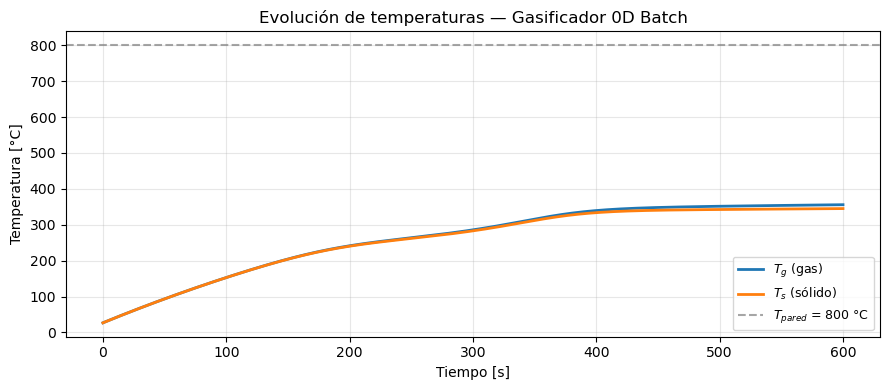

In [94]:
fig, ax = plot_temperatures(
    gasifier,
    T_ref       = T_wall,
    T_ref_label = f"$T_{{pared}}$ = {T_wall - 273.15:.0f} °C",
)
ax.set_title("Evolución de temperaturas — Gasificador 0D Batch")
plt.show()

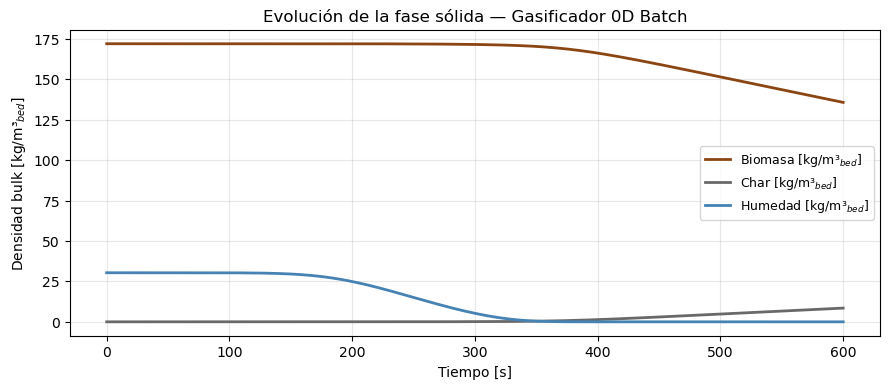

In [95]:
fig, ax = plot_solid_evolution(gasifier)
ax.set_title("Evolución de la fase sólida — Gasificador 0D Batch")
plt.show()

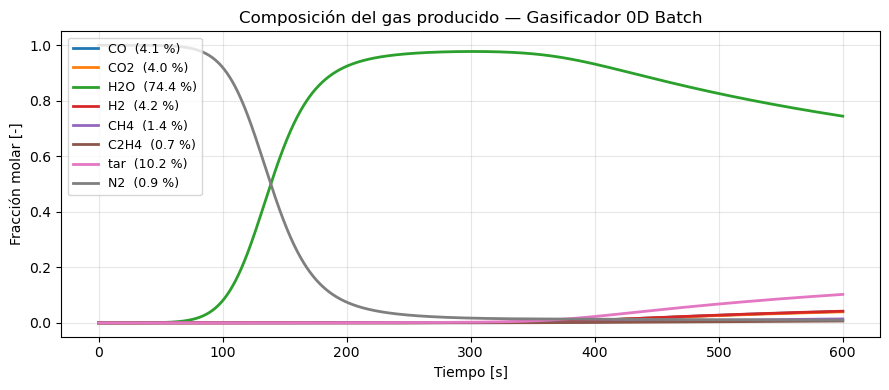

In [96]:
fig, ax = plot_gas_composition(gasifier)
ax.set_title("Composición del gas producido — Gasificador 0D Batch")
plt.show()

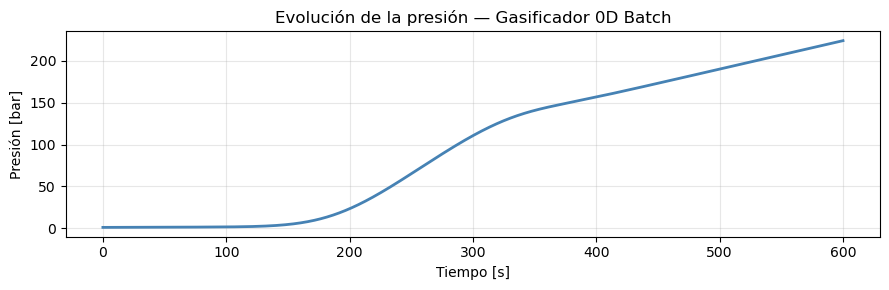

In [97]:
fig, ax = plot_pressure(gasifier)
ax.set_title("Evolución de la presión — Gasificador 0D Batch")
plt.show()

## 10. Verificación de balances

In [84]:
balances = check_balances(gasifier, params, verbose=False)
display_balances(balances)

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,+5.8144e+01,
Δm_sólido,-5.8144e+01,
Flujo_masa_neto,+0.0000e+00,
★ Cierre,+2.8296e-05,0.000 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+1.062e+02 / +2.975e+00,+0.000e+00 / +0.000e+00,+1.062e+02 / +2.975e+00,+0.000e+00 / +0.000e+00
CO2,+1.022e+02 / +4.499e+00,+0.000e+00 / +0.000e+00,+1.022e+02 / +4.499e+00,+0.000e+00 / +0.000e+00
H2O,+1.914e+03 / +3.449e+01,+0.000e+00 / +0.000e+00,+1.914e+03 / +3.449e+01,+0.000e+00 / +0.000e+00
H2,+1.080e+02 / +2.177e-01,+0.000e+00 / +0.000e+00,+1.080e+02 / +2.177e-01,+0.000e+00 / +0.000e+00
O2,-3.600e-15 / -1.152e-16,+0.000e+00 / +0.000e+00,-3.600e-15 / -1.152e-16,+0.000e+00 / +0.000e+00
CH4,+3.618e+01 / +5.805e-01,+0.000e+00 / +0.000e+00,+3.618e+01 / +5.805e-01,+0.000e+00 / +0.000e+00
C2H4,+1.681e+01 / +4.716e-01,+0.000e+00 / +0.000e+00,+1.681e+01 / +4.716e-01,+0.000e+00 / +0.000e+00
tar,+2.634e+02 / +1.491e+01,+0.000e+00 / +0.000e+00,+2.634e+02 / +1.491e+01,+0.000e+00 / +0.000e+00
N2,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00,+0.000e+00 / +0.000e+00
── TOTAL ──,+2.547e+03 / +5.814e+01,+0.000e+00 / +0.000e+00,+2.547e+03 / +5.814e+01,+0.000e+00 / +0.000e+00



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+1.2987e+08,acumulación gas
Fh_conv_neto,+0.0000e+00,exacto
Q_gs (gas→sólido),+2.5109e+08,acum. ODE — exacto
Q_wall (pared→gas),+2.5807e+08,thermal_bc
Q_mt (sól→gas),+1.2289e+08,acum. ODE — exacto
★ Cierre_Hg,-4.0204e+01,-0.000 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+8.2953e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+2.5109e+08,acum. ODE — exacto
Q_rxn (exacto),-1.6814e+08,acum. ODE — exacto
★ Cierre_Hs,+9.5129e+01,0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+2.1282e+08,acumulación total
Fh_conv_neto,+0.0000e+00,exacto
Q_wall,+2.5807e+08,thermal_bc
Q_rxn (exacto),-1.6814e+08,acum. ODE
Q_mt (exacto),+1.2289e+08,acum. ODE
★ Cierre global,+5.4925e+01,0.000 % ✓ OK


## Interpretación de balances

**★ Cierre numérico** — residual debe ser ≈ 0 (umbral: < 1 % del término mayor)  
**~ Residual físico** — residual = cantidad producida o consumida; se espera ≠ 0, es información útil

### Convención de símbolos

| Símbolo | Tipo | Debe ser |
|---------|------|----------|
| ★ | Cierre numérico (masa total, ★ Cierre por especie, energías, balance global) | ≈ 0 |
| ~ | Residual físico (Fuente_rxn por especie, masa sólida) | ≠ 0 — muestra cuánto reaccionó |
| ✓ OK | Cierre ★ dentro del umbral (< 1 %) | — |
| ⚠ REVISAR | Cierre ★ fuera del umbral | Investigar causa raíz |

### Formato de la tabla de especies gas

Cada celda muestra **mol/m³_bed / kg/m³_bed** (ambos normalizados por volumen de lecho). Las columnas son:

| Columna | Descripción |
|---------|-------------|
| `ΔC [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Acumulación en el reactor: estado final − inicial |
| `Flujo [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Flujo neto por los contornos: ∫(F_in − F_out) dt |
| `~ Fuente_rxn [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | Moles/masa producidos por reacciones = ΔC − Flujo (residual físico, ≠ 0) |
| `★ Cierre [mol/m³_bed | kg/m³_bed]`|`ΔC [mol/m³_bed | kg/m³_bed]` | ΔC − Flujo − Fuente_rxn ≈ 0 (numérico, por construcción) |
| `── TOTAL ──` | Suma de todas las especies; kg/m³ ≈ Δm_gas del balance de masa total |

### Valores esperados en este caso (0D Batch — reactor sellado)

| Balance | Tipo | Qué esperar |
|---------|------|-------------|
| ★ Masa total (gas + sólido) | Numérico | ≈ 0: masa sólida consumida = masa de gas acumulada |
| ~ Fuente_rxn por especie | Físico | ≠ 0: moles producidos por pirólisis y secado |
| ★ Cierre por especie | Numérico | ≈ 0: ΔC_i − Flujo_i − Fuente_rxn_i |
| TOTAL kg/m³ (Fuente_rxn) | Físico | ≈ \|Δm_sólido\|: toda la masa sólida consumida pasa a gas |
| ★ Energía gas (Hg) | Numérico | ≈ 0: con acumulador Q_mt exacto en el sv |
| ★ Energía sólido (Ts) | Numérico | ≈ 0: con H_j(T) = ∫Cp dT y acumulador Q_rxn |
| ★ Balance global (Hg+Hs) | Numérico | ≈ 0: cierre combinado de gas y sólido |
| ~ Masa sólida por componente | Físico | ≠ 0: biomasa y humedad consumidas (−); char producido (+) |

### Nota sobre el modo Batch

`Flujo = 0` en todas las especies: en batch con `v_gas_in=None` y `v_out=0.0`
el reactor es **sellado** — no entra ni sale gas. El `Flujo [mol|`ΔC [mol/m³_bed | kg/m³_bed]` es cero
para todas las especies y la columna `~ Fuente_rxn` refleja directamente la producción
de cada especie por las reacciones (ΔC_i = Fuente_rxn_i).

La suma `TOTAL kg/m³ (Fuente_rxn) ≈ |Δm_sólido|` confirma el cruce con el balance de masa total.

### Si algún balance ★ no cierra (> 1 %)

- **Energía sólido > 1 %**: verificar que `solid_config` contiene `h_fns`
  (integrales ∫Cp dT, no el proxy Cp·T). Ver `.claude/rules/balance-rules.md`.
- **Energía gas > 1 %**: verificar que el acumulador `Q_mt_acc` está en el sv
  y que `q_masstransfer` se calcula con `h_i(Ts)`, no `h_i(Tg)`.
- **Masa total > 1 %**: verificar consistencia de `epsi_r` en flujos de entrada/salida.
- **★ Cierre por especie ≠ 0**: no debería ocurrir (por construcción); indicaría un bug aritmético.
- **Balance global > 1 %**: normalmente implica que uno de los balances individuales falla.

## Conclusiones

### Qué demuestra este tutorial

1. **N=1 → modelo 0D**: el gasificador se trata como un único volumen perfectamente mezclado;
   no hay gradientes axiales ni velocidades de cara internas.

2. **Batch sellado** (`v_gas_in=None`, `v_out=0.0`): sin flujo de gas externo y sin salida,
   el sistema evoluciona solo por reacciones internas (secado → pirólisis). La energía entra
   desde la pared y la **presión sube libremente** conforme el sólido produce gas.

3. **Limitación del modo batch sellado**: la presión puede subir decenas de bar en pocos
   minutos, lo que hace difícil interpretar el efecto de parámetros como T_wall, mc_wb o
   T_MAX de forma aislada. Para explorar esos efectos, usar el modo semibatch (Tutorial 02)
   donde la válvula de alivio mantiene P bajo control.

4. **Etapas observables**: primero el secado (pico de H₂O), luego la pirólisis  
   (aparición de CO, CO₂, CH₄, H₂) conforme Ts supera los ~400–500 °C.

5. **Diferencia Tg/Ts**: el gas se calienta más rápido que el sólido por su menor  
   inercia térmica; la diferencia se reduce cuando el sólido se agota.

6. **Cierres de balance**: masa total ★ y energías ★ deben cerrar a < 1 %;  
   las fuentes de reacción (~) son residuales físicos esperados (≠ 0).

### Qué probar a continuación

- **Modo semibatch** (`v_out > 0`): controla la presión con una válvula de alivio y permite
  explorar el efecto de T_wall, mc_wb y T_MAX de forma limpia → `test_gasifier_02_0D_semibatch.ipynb`
- **Pasar a 1D**: ¿qué gradientes axiales aparecen con N=10? → `test_gasifier_10_1D_batch.ipynb`